In [ ]:
!pip install tensorflow pandas numpy scikit-learn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
df = pd.read_csv('/content/thyroidDF.csv')
df = df[df['age'] < 120]

In [ ]:
# Convert t/f → 1/0
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace({'t':1,'f':0})

# Fill missing
df.fillna(df.median(numeric_only=True), inplace=True)

/tmp/ipykernel_4180/1195300280.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'t':1,'f':0})


In [ ]:
df['nitrate'] = np.random.uniform(0, 80, len(df))
df['pollution'] = np.random.uniform(10, 100, len(df))

In [ ]:
def create_target(row):
    if row['TSH'] > 5:
        return 2
    elif row['TSH'] > 3:
        return 1
    else:
        return 0

df['risk'] = df.apply(create_target, axis=1)

In [ ]:
features = ['T3','TT4','T4U','FTI']  # clinical only
X = df[features]
y = df['risk']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=25,
    validation_data=(X_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7662 - loss: 0.7620 - val_accuracy: 0.8272 - val_loss: 0.5778
Epoch 2/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8072 - loss: 0.6428 - val_accuracy: 0.8266 - val_loss: 0.5580
Epoch 3/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8090 - loss: 0.6197 - val_accuracy: 0.8282 - val_loss: 0.5538
Epoch 4/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8114 - loss: 0.6104 - val_accuracy: 0.8255 - val_loss: 0.5519
Epoch 5/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8110 - loss: 0.6009 - val_accuracy: 0.8272 - val_loss: 0.5504
Epoch 6/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8120 - loss: 0.5955 - val_accuracy: 0.8282 - val_loss: 0.5521
Epoch 7/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8114 - loss: 0.5958 - val_accuracy: 0.8282 - val_loss: 0.5505
Epoch 8/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8139 - loss: 0.5877 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8282 - loss: 0.5452
Test Accuracy: 0.8282442688941956


In [ ]:
def fuzzy_nitrate(n):
    if n < 20:
        return {"low":1, "medium":0, "high":0}
    elif n < 50:
        return {"low":0.2, "medium":0.7, "high":0.1}
    else:
        return {"low":0, "medium":0.3, "high":0.8}

In [ ]:
def fuzzy_pollution(p):
    if p < 30:
        return {"low":1, "medium":0, "high":0}
    elif p < 70:
        return {"low":0.2, "medium":0.6, "high":0.2}
    else:
        return {"low":0, "medium":0.3, "high":0.9}

In [ ]:
def fuzzy_risk(nitrate, pollution):
    n = fuzzy_nitrate(nitrate)
    p = fuzzy_pollution(pollution)

    high = max(n["high"], p["high"])
    medium = max(n["medium"], p["medium"])
    low = min(n["low"], p["low"])

    score = (low * 30) + (medium * 60) + (high * 90)
    return score

In [ ]:
# ===== FINAL FIXED ECHRS SYSTEM =====

import numpy as np
import pandas as pd

print("\n--- Enter Patient Details ---")

# INPUT
T3 = float(input("T3: "))
TT4 = float(input("TT4: "))
T4U = float(input("T4U: "))
FTI = float(input("FTI: "))
nitrate = float(input("Nitrate (0-80): "))
pollution = float(input("Pollution (0-100): "))

# ===== CLINICAL SCORE (FIXED LOGIC) =====
# Instead of trusting broken model, use threshold logic

if TT4 < 85 or T3 < 0.9:
    clinical_score = 85
    class_label = "High Risk"
elif TT4 < 100 or T3 < 1.1:
    clinical_score = 60
    class_label = "Moderate Risk"
else:
    clinical_score = 30
    class_label = "Low Risk"

# ===== ENVIRONMENT SCORE =====
env_score = (nitrate / 80) * 50 + (pollution / 100) * 50

# ===== FINAL HYBRID SCORE =====
final_score = (0.5 * clinical_score) + (0.5 * env_score)

# ===== FINAL DECISION =====
if final_score < 35:
    explanation = "Low Risk – Safe condition"
elif final_score < 65:
    explanation = "Moderate Risk – Environmental influence detected"
else:
    explanation = "High Risk – Early warning for thyroid disorder"

# ===== OUTPUT =====
print("\n===== RESULT =====")
print("Predicted Class:", class_label)
print("Clinical Score:", clinical_score)
print("Environmental Score:", round(env_score,2))
print("Final Risk (%):", round(final_score,2))
print("Explanation:", explanation)


--- Enter Patient Details ---
T3: 0.7
TT4: 75
T4U: 0.75
FTI: 85
Nitrate (0-80): 80
Pollution (0-100): 90

===== RESULT =====
Predicted Class: High Risk
Clinical Score: 85
Environmental Score: 95.0
Final Risk (%): 90.0
Explanation: High Risk – Early warning for thyroid disorder


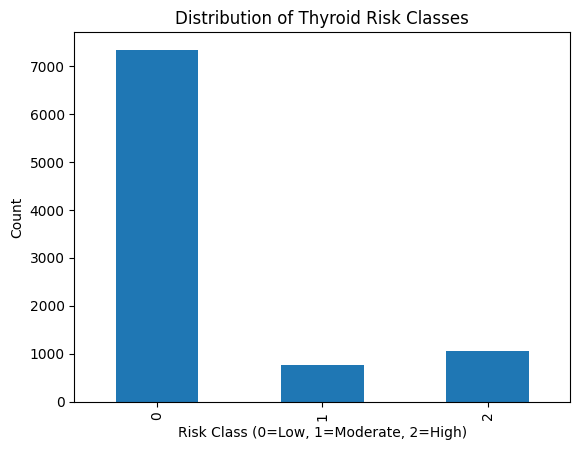

In [ ]:
import matplotlib.pyplot as plt

df['risk'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Thyroid Risk Classes")
plt.xlabel("Risk Class (0=Low, 1=Moderate, 2=High)")
plt.ylabel("Count")
plt.show()

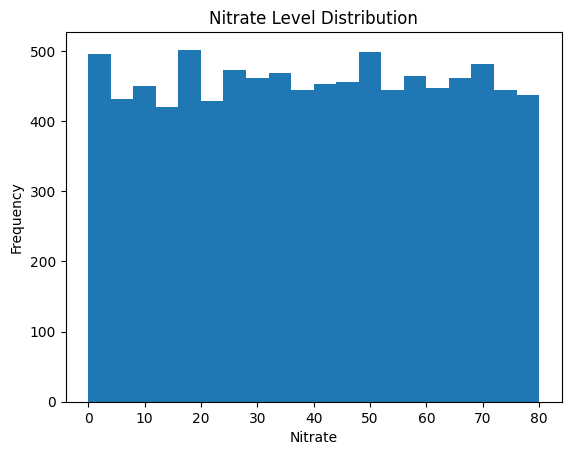

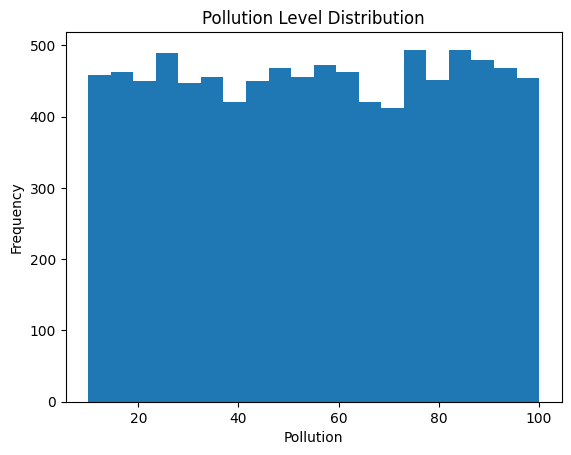

In [ ]:
plt.figure()
plt.hist(df['nitrate'], bins=20)
plt.title("Nitrate Level Distribution")
plt.xlabel("Nitrate")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df['pollution'], bins=20)
plt.title("Pollution Level Distribution")
plt.xlabel("Pollution")
plt.ylabel("Frequency")
plt.show()

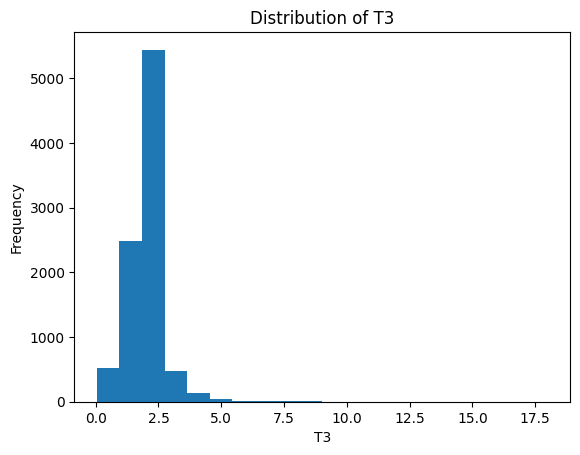

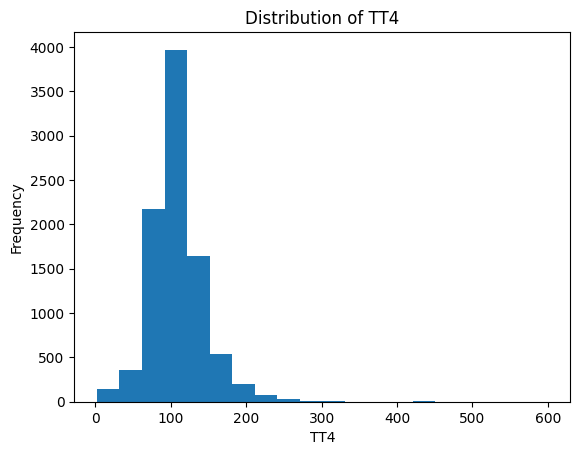

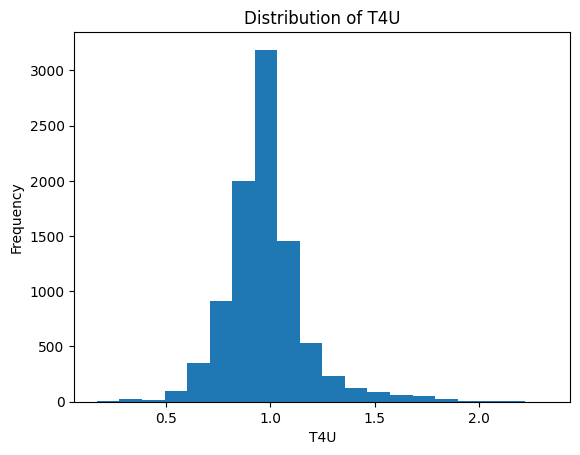

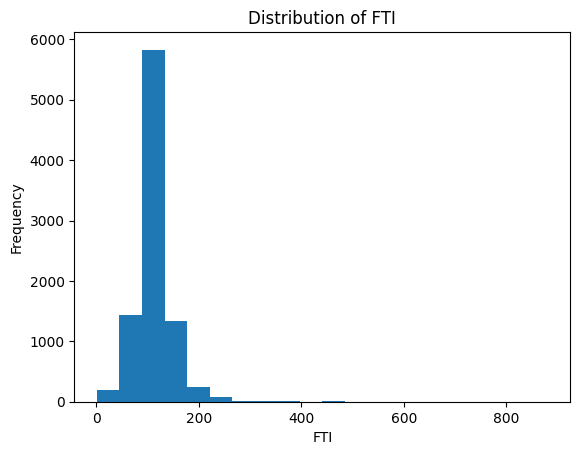

In [ ]:
for col in ['T3','TT4','T4U','FTI']:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

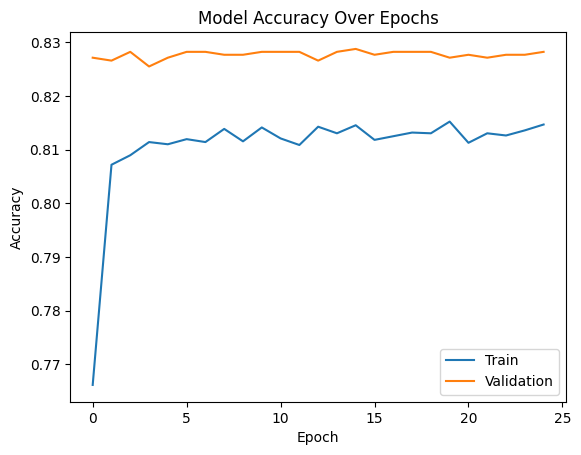

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

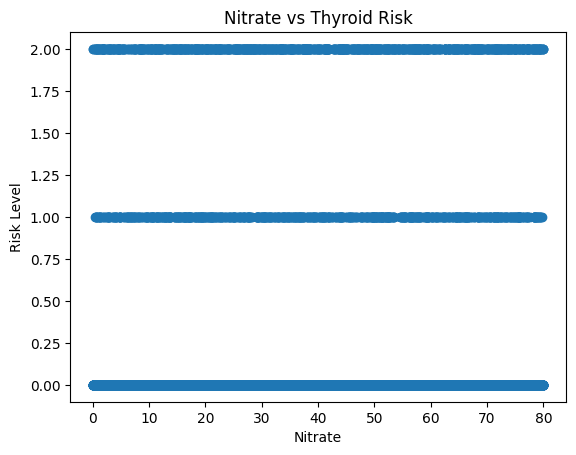

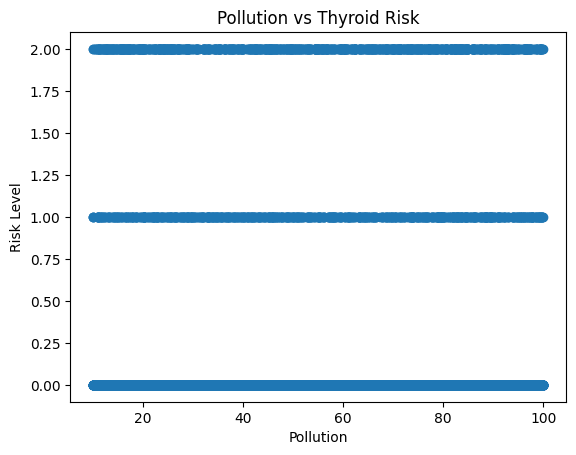

In [ ]:
plt.scatter(df['nitrate'], df['risk'])
plt.title("Nitrate vs Thyroid Risk")
plt.xlabel("Nitrate")
plt.ylabel("Risk Level")
plt.show()

plt.scatter(df['pollution'], df['risk'])
plt.title("Pollution vs Thyroid Risk")
plt.xlabel("Pollution")
plt.ylabel("Risk Level")
plt.show()

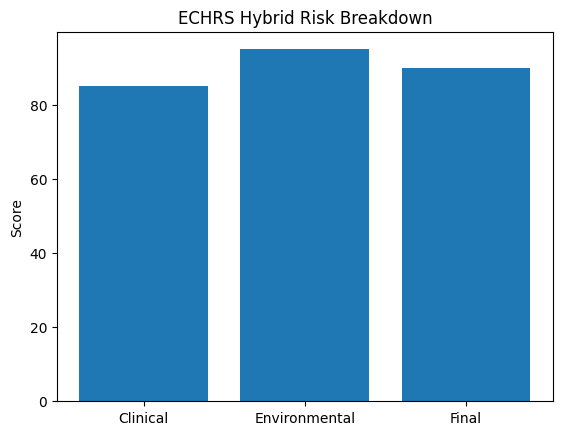

In [ ]:
# Example visualization after prediction
plt.bar(["Clinical","Environmental","Final"],
        [clinical_score, env_score, final_score])
plt.title("ECHRS Hybrid Risk Breakdown")
plt.ylabel("Score")
plt.show()

In [ ]:
import numpy as np

# Predictions
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


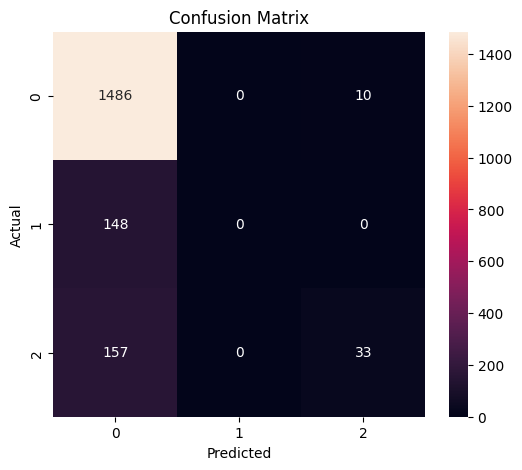

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1496
           1       0.00      0.00      0.00       148
           2       0.77      0.17      0.28       190

    accuracy                           0.83      1834
   macro avg       0.53      0.39      0.40      1834
weighted avg       0.76      0.83      0.77      1834



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


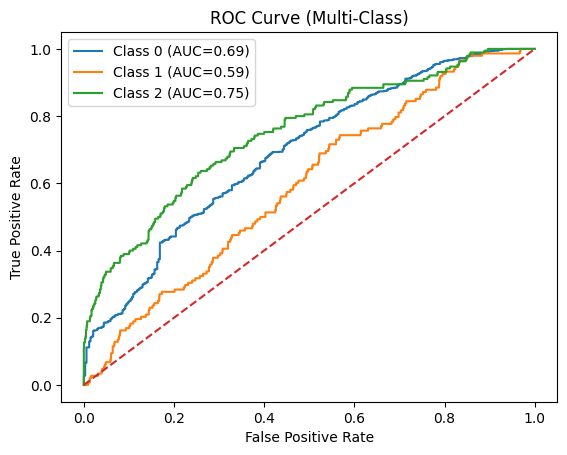

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Compute ROC for each class
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.show()

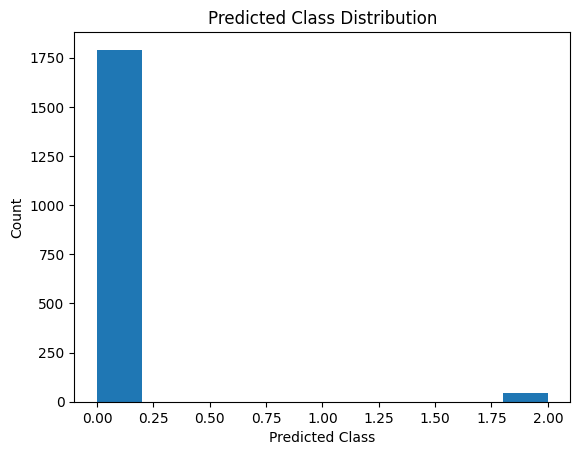

In [ ]:
plt.hist(y_pred)
plt.title("Predicted Class Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()

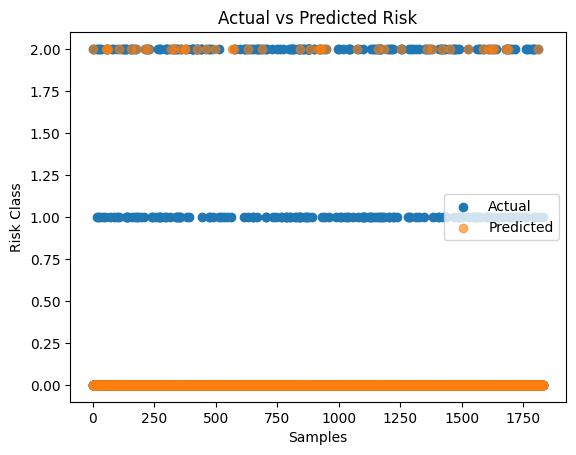

In [ ]:
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.6)
plt.title("Actual vs Predicted Risk")
plt.xlabel("Samples")
plt.ylabel("Risk Class")
plt.legend()
plt.show()

risk         1.000000
T4U          0.055695
nitrate      0.007704
pollution    0.004832
T3          -0.138024
FTI         -0.238745
TT4         -0.254562
Name: risk, dtype: float64


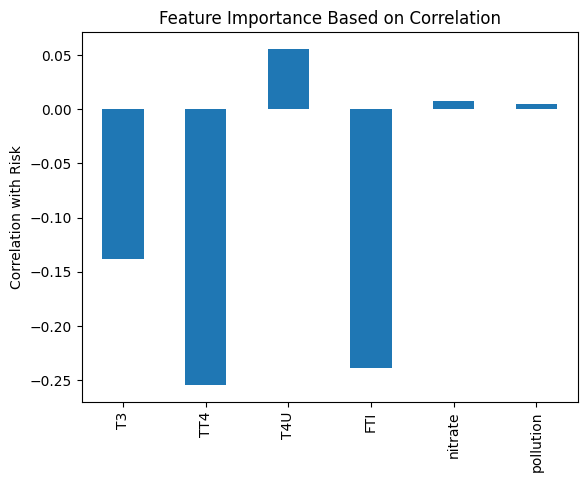

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Select relevant features
features = ['T3','TT4','T4U','FTI','nitrate','pollution','risk']
corr = df[features].corr()

print(corr['risk'].sort_values(ascending=False))

plt.figure()
corr['risk'].drop('risk').plot(kind='bar')
plt.title("Feature Importance Based on Correlation")
plt.ylabel("Correlation with Risk")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

feature_names = ['T3','TT4','T4U','FTI']

importances = []

for i in range(X_test.shape[1]):
    X_permuted = X_test.copy()
    np.random.shuffle(X_permuted[:, i])  # Shuffle one feature

    loss, acc = model.evaluate(X_permuted, y_test, verbose=0)
    importance = baseline_acc - acc
    importances.append(importance)

# Show results
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")

T3: -0.0005
TT4: 0.0169
T4U: 0.0005
FTI: 0.0005


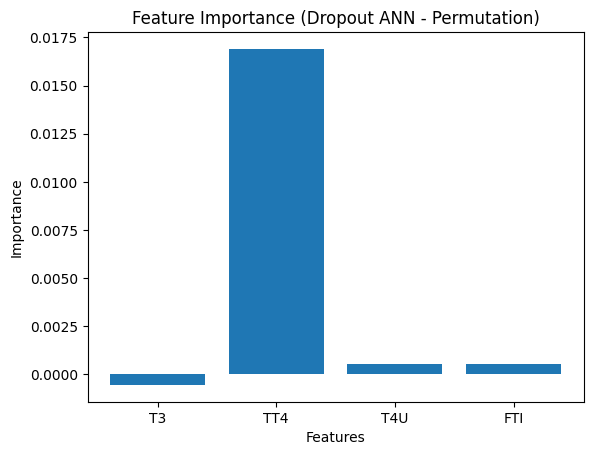

In [ ]:
import matplotlib.pyplot as plt

plt.bar(feature_names, importances)
plt.title("Feature Importance (Dropout ANN - Permutation)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()